In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from astropy import units as u
from astropy import constants as cons
from matplotlib import pyplot as plt

from config import *
from main import *


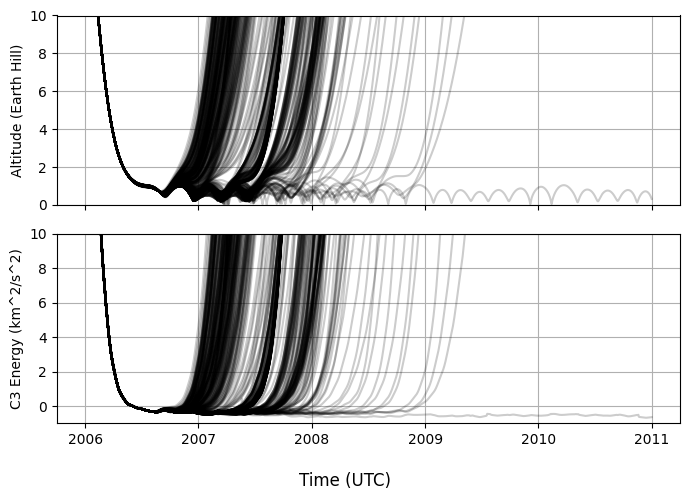

In [7]:
obj_name = '2006 RH120'

column1 = f'Ast{obj_name.replace(" ", "")} Earth Altitude'
column2 = f'Ast{obj_name.replace(" ", "")} Earth C3Energy'

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

for i in range(500):
    name = f"MCWorkspace/Data/{obj_name}_ephem{i}.csv"
    
    try:
        data = pd.read_csv(name)
    except FileNotFoundError:
        continue

    data1 = data[column1] / (1.4714e6)
    data2 = data[column2]

    time_axis = data[f'Ast{obj_name.replace(" ", "")} UTCGregorian'].values
    time_axis[0] = '01 Jan 2006 00:00:01.000'
    time_axis = [datetime.strptime(t, '%d %b %Y %H:%M:%S.%f') for t in time_axis]

    time_axis = np.array(time_axis)

    ax.plot(time_axis, data1, color = 'black', alpha = 0.2)
    bx.plot(time_axis, data2, color = 'black', alpha = 0.2)

ax.set_ylabel('Altitude (Earth Hill)')
bx.set_ylabel('C3 Energy (km^2/s^2)')
ax.grid()
bx.grid()

ax.set_ylim(0, 10)
bx.set_ylim(-1, 10)

fig.supxlabel('Time (UTC)')
fig.tight_layout()


In [3]:
import astropy.units as u

(1 * u.AU).to(u.km)

<Quantity 1.49597871e+08 km>

In [1]:
1.5e6 / 1.4714e6

1.0194372706266142

In [5]:
test = 1 * u.AU * (cons.M_earth / (3 * cons.M_sun))**(1/3)
test.to(u.km)

<Quantity 1496558.48134108 km>